In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

# Establish project root
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("Seed:", SEED)

Project root: /home/kalpe/projects/adaptive_rl_anomaly_detection
PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Device: cuda
Seed: 42


In [2]:
import joblib

TEST_DATA_PATH = PROJECT_ROOT / "evaluation_results" / "test_data.joblib"
print(f"Loading test data from: {TEST_DATA_PATH}")
assert TEST_DATA_PATH.exists(), f"File not found: {TEST_DATA_PATH}"

test_data = joblib.load(TEST_DATA_PATH)
print("Keys in test_data.joblib:", list(test_data.keys()))

X_test = test_data["X_test"].reset_index(drop=True)
y_test_raw = test_data["y_test"].reset_index(drop=True)

# Convert labels to binary (0 = Benign/Normal, 1 = Attack/Anomaly)
y_test = (y_test_raw != 0).astype(np.int64)

print("\n--- Test Data Shapes & Distributions ---")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("\nClass distribution:")
unique_labels, counts = np.unique(y_test, return_counts=True)
for label, count in zip(unique_labels, counts):
    name = "Normal (0)" if label == 0 else "Anomaly (1)"
    print(f"  {name:12s}: {count:7d} ({count / len(y_test) * 100:.2f}%)")

# Assertions per frozen test spec
assert X_test.shape == (504160, 70)
assert y_test.shape == (504160,)
assert counts[0] == 419012 and counts[1] == 85148
assert np.all(np.isin(unique_labels, [0, 1]))

print("\n[OK] Untouched test dataset loaded and verified against canonical split.")

Loading test data from: /home/kalpe/projects/adaptive_rl_anomaly_detection/evaluation_results/test_data.joblib
Keys in test_data.joblib: ['X_test', 'y_test']

--- Test Data Shapes & Distributions ---
X_test shape: (504160, 70)
y_test shape: (504160,)

Class distribution:
  Normal (0)  :  419012 (83.11%)
  Anomaly (1) :   85148 (16.89%)

[OK] Untouched test dataset loaded and verified against canonical split.


In [3]:
MODEL_SCORES_PATH = PROJECT_ROOT / "evaluation_results" / "model_scores.joblib"
print(f"Loading test detector scores from: {MODEL_SCORES_PATH}")
assert MODEL_SCORES_PATH.exists(), f"File not found: {MODEL_SCORES_PATH}"

raw_model_scores = joblib.load(MODEL_SCORES_PATH)
print("Keys in model_scores.joblib:", list(raw_model_scores.keys()))

# Align dictionary keys to canonical MODEL_ORDER ('isolation_forest', 'lof', 'ocsvm', 'autoencoder')
test_scores = {
    "isolation_forest": np.asarray(raw_model_scores["if_scores"], dtype=np.float64),
    "lof": np.asarray(raw_model_scores["lof_scores"], dtype=np.float64),
    "ocsvm": np.asarray(raw_model_scores["svm_scores"], dtype=np.float64),
    "autoencoder": np.asarray(raw_model_scores["ae_scores"], dtype=np.float64),
}

print("\n--- Test Detector Scores Verification ---")
for name, scores in test_scores.items():
    print(f"{name:18s}: shape={scores.shape}, min={scores.min():.6f}, max={scores.max():.6f}")
    assert scores.shape == (len(X_test),)
    assert np.all(np.isfinite(scores))

print("\n[OK] All 4 detector test score arrays align with X_test (504,160 samples).")

Loading test detector scores from: /home/kalpe/projects/adaptive_rl_anomaly_detection/evaluation_results/model_scores.joblib
Keys in model_scores.joblib: ['if_scores', 'lof_scores', 'svm_scores', 'ae_scores']

--- Test Detector Scores Verification ---
isolation_forest  : shape=(504160,), min=0.319992, max=0.754017
lof               : shape=(504160,), min=-2.317411, max=12616.581210
ocsvm             : shape=(504160,), min=-75.886006, max=100.205412
autoencoder       : shape=(504160,), min=0.000068, max=2771.118408

[OK] All 4 detector test score arrays align with X_test (504,160 samples).


In [4]:
from sklearn.model_selection import train_test_split
from src.rl.state import S3StateBuilder, STATE_DIM
from src.utils.timer import Timer

PROCESSED_PATH = PROJECT_ROOT / "notebooks" / "datasets" / "processed" / "cicids2017_processed.parquet"
assert PROCESSED_PATH.exists(), f"Processed dataset missing at: {PROCESSED_PATH}"

# 1. Recreate the canonical validation split to obtain X_val for normalizer fitting
print("Loading dataset to extract validation reference...")
df_processed = pd.read_parquet(PROCESSED_PATH)
X_all = df_processed.drop(columns=["Label"])
y_all = (df_processed["Label"] != 0).astype(int)

X_train_full, _, y_train_full, _ = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all,
)

_, X_val, _, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train_full,
)
X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

assert len(X_val) == 201664

# 2. Load trained baseline models to score X_val
MODEL_DIR = PROJECT_ROOT / "notebooks" / "trained_models"
base_models = {
    "isolation_forest": joblib.load(MODEL_DIR / "isolation_forest.joblib"),
    "lof": joblib.load(MODEL_DIR / "local_outlier_factor.joblib"),
    "ocsvm": joblib.load(MODEL_DIR / "one_class_svm.joblib"),
    "autoencoder": joblib.load(MODEL_DIR / "autoencoder.joblib"),
}

# Ensure AutoEncoder inference executes on configured device
ae_model = base_models["autoencoder"]
ae_model._device = torch.device(DEVICE)
ae_model._model = ae_model._model.to(ae_model._device)

val_scores = {}
with Timer("Validation Reference Scoring"):
    for name in ["isolation_forest", "lof", "ocsvm", "autoencoder"]:
        val_scores[name] = np.asarray(base_models[name].anomaly_score(X_val), dtype=np.float64)

# 3. Fit S3StateBuilder on validation scores and build test_state_s3
state_builder = S3StateBuilder()
state_builder.fit_normalizers(val_scores)

test_state_s3 = state_builder.build(
    raw_scores=test_scores,
    traffic_features=X_test,
)

print("\n--- Test S3 State Verification ---")
print("Test S3 state shape:", test_state_s3.shape)
print("Test S3 dtype      :", test_state_s3.dtype)

assert test_state_s3.shape == (len(X_test), STATE_DIM)
assert test_state_s3.dtype == np.float32
assert np.all(np.isfinite(test_state_s3))
assert np.all(test_state_s3[:, :4] >= 0.0)
assert np.all(test_state_s3[:, :4] <= 1.0)

print("\n[OK] Test S3 state constructed without data leakage (normalizers fit on validation only).")

Loading dataset to extract validation reference...


2026-08-17 15:05:04 | INFO     | AdaptiveRL | Validation Reference Scoring started.
2026-08-17 15:05:52 | INFO     | AdaptiveRL | Validation Reference Scoring completed in 48.5120 seconds.



--- Test S3 State Verification ---
Test S3 state shape: (504160, 14)
Test S3 dtype      : float32

[OK] Test S3 state constructed without data leakage (normalizers fit on validation only).


In [5]:
from src.rl.agent import PPOAgent, PPOConfig
from src.rl.action import ActionProjector, ACTION_DIM, DETECTOR_NAMES
from src.rl.environment import AnomalyEnsembleEnv
from src.rl.reward import FINAL_REWARD_SCHEME
from src.evaluation.metrics import MetricsEvaluator
from src.utils.timer import Timer

# 1. Load the frozen best checkpoint
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "rl" / "best.pt"
assert CHECKPOINT_PATH.exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"

agent_config = PPOConfig(
    state_dim=STATE_DIM,
    action_dim=ACTION_DIM,
    device=DEVICE,
)
ppo_agent = PPOAgent(agent_config)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
ppo_agent.load_state_dict(checkpoint["agent_state"])

print("--- Loaded PPO Checkpoint ---")
print("Checkpoint file   :", CHECKPOINT_PATH)
print("Trained updates   :", checkpoint["n_updates"])
print("Trained timesteps :", checkpoint["n_timesteps"])
print("Best val reward   :", checkpoint["best_val_reward"])

# 2. Build the frozen test environment (deterministic / shuffle=False)
test_env = AnomalyEnsembleEnv(
    states=test_state_s3,
    y_true=y_test.to_numpy(dtype=np.int64),
    threshold=0.5,
    action_projector=ActionProjector(method="softmax"),
    reward_scheme=FINAL_REWARD_SCHEME,
    shuffle=False,
    seed=SEED,
)

# 3. Step deterministically through all test samples to collect predictions and dynamic weights
all_y_pred = []
all_scores = []
all_weights = []

state = test_env.reset()
done = False

with Timer("PPO Test Set Inference"):
    while not done:
        # Deterministic inference (policy mean)
        action = ppo_agent.select_action(state, explore=False)
        result = test_env.step(action)
        
        all_scores.append(result.info["ensemble_score"])
        all_y_pred.append(result.info["y_pred"])
        all_weights.append(result.info["weights"])
        
        state = result.next_state
        done = result.done

ppo_test_scores = np.asarray(all_scores, dtype=np.float64)
ppo_test_preds = np.asarray(all_y_pred, dtype=np.int64)
ppo_test_weights = np.asarray(all_weights, dtype=np.float64)

# 4. Compute comprehensive evaluation metrics
evaluator = MetricsEvaluator()
ppo_eval_result = evaluator.evaluate(
    y_true=y_test.to_numpy(),
    y_pred=ppo_test_preds,
    anomaly_scores=ppo_test_scores,
    model_name="PPO Adaptive Ensemble",
)

print("\n" + ppo_eval_result.summary())

assert ppo_test_scores.shape == (len(X_test),)
assert ppo_test_preds.shape == (len(X_test),)
assert ppo_test_weights.shape == (len(X_test), ACTION_DIM)
print("\n[OK] PPO Adaptive Ensemble test evaluation completed on 504,160 samples.")

2026-08-17 15:06:32 | INFO     | AdaptiveRL | PPO Test Set Inference started.


--- Loaded PPO Checkpoint ---
Checkpoint file   : /home/kalpe/projects/adaptive_rl_anomaly_detection/checkpoints/rl/best.pt
Trained updates   : 40
Trained timesteps : 81920
Best val reward   : 0.5475940177721358


2026-08-17 15:10:08 | INFO     | AdaptiveRL | PPO Test Set Inference completed in 224.2507 seconds.



Evaluation Summary: PPO Adaptive Ensemble
Samples          : 504160 (Normal: 419012, Anomaly: 85148)
------------------------------------------------------------
Accuracy         : 0.7655
Precision        : 0.3758
Recall           : 0.5878
F1 Score         : 0.4585
ROC-AUC          : 0.7719
PR-AUC           : 0.4252
------------------------------------------------------------
True Positive Rate  (TPR) : 0.5878
True Negative Rate  (TNR) : 0.8016
False Positive Rate (FPR) : 0.1984
False Negative Rate (FNR) : 0.4122
------------------------------------------------------------
Confusion Matrix:
    TN: 335881   FP: 83131   
    FN: 35099    TP: 50049   

[OK] PPO Adaptive Ensemble test evaluation completed on 504,160 samples.


In [6]:
import pandas as pd

# 1. Construct DataFrame of per-sample dynamic detector weights
weights_df = pd.DataFrame(
    ppo_test_weights,
    columns=[f"weight_{name}" for name in DETECTOR_NAMES],
)

# 2. Compute summary statistics
weight_stats = weights_df.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

print("=" * 75)
print("PPO DYNAMIC DETECTOR WEIGHT STATISTICS (TEST SET: 504,160 SAMPLES)")
print("=" * 75)
print(weight_stats.to_string())
print("-" * 75)

# Verify weight simplex constraints across all test samples
assert np.allclose(weights_df.sum(axis=1), 1.0, atol=1e-5)
assert (weights_df >= 0.0).all().all()
print("[OK] All test weight allocations strictly satisfy simplex constraints (w >= 0, sum(w) = 1).")

# 3. Analyze weight distributions split by ground truth class
weights_df["TrueLabel"] = y_test.values

print("\n" + "=" * 75)
print("MEAN WEIGHT ALLOCATION BY TRUE CLASS")
print("=" * 75)
class_weights = weights_df.groupby("TrueLabel")[[f"weight_{name}" for name in DETECTOR_NAMES]].mean()
class_weights.index = ["Normal (0)", "Anomaly (1)"]
print(class_weights.to_string())
print("=" * 75)

PPO DYNAMIC DETECTOR WEIGHT STATISTICS (TEST SET: 504,160 SAMPLES)
                             mean       std       min       25%       50%       75%       max
weight_isolation_forest  0.156311  0.115286  0.003172  0.053823  0.123809  0.250311  0.489773
weight_lof               0.268938  0.252607  0.007034  0.073770  0.161716  0.411350  0.973190
weight_ocsvm             0.309601  0.240166  0.003688  0.099105  0.256459  0.481151  0.938989
weight_autoencoder       0.265149  0.187521  0.009555  0.102574  0.231030  0.376029  0.749529
---------------------------------------------------------------------------
[OK] All test weight allocations strictly satisfy simplex constraints (w >= 0, sum(w) = 1).

MEAN WEIGHT ALLOCATION BY TRUE CLASS
             weight_isolation_forest  weight_lof  weight_ocsvm  weight_autoencoder
Normal (0)                  0.169585    0.286225      0.290723            0.253467
Anomaly (1)                 0.090994    0.183870      0.402499            0.322637


In [7]:
import pandas as pd
from src.ensemble.static_ensemble import StaticEnsemble
from src.evaluation.metrics import MetricsEvaluator

# 1. Evaluate Static Equal-Weight Ensemble (0.25 on each detector) as a direct baseline
static_weights = {"if": 0.25, "lof": 0.25, "svm": 0.25, "ae": 0.25}
static_ensemble = StaticEnsemble(weights=static_weights, normalization="percentile")

# Fit static ensemble normalizer & threshold using validation reference
static_val_scores = {
    "if": val_scores["isolation_forest"],
    "lof": val_scores["lof"],
    "svm": val_scores["ocsvm"],
    "ae": val_scores["autoencoder"],
}
static_ensemble.fit(
    validation_scores=static_val_scores,
    y_validation=y_val.to_numpy(),
    threshold_strategy="percentile",
    threshold_percentile=95.0,
)

static_test_scores_dict = {
    "if": test_scores["isolation_forest"],
    "lof": test_scores["lof"],
    "svm": test_scores["ocsvm"],
    "ae": test_scores["autoencoder"],
}
static_test_scores = static_ensemble.anomaly_score(static_test_scores_dict)
static_test_preds = static_ensemble.predict(static_test_scores_dict)

evaluator = MetricsEvaluator()
static_eval_result = evaluator.evaluate(
    y_true=y_test.to_numpy(),
    y_pred=static_test_preds,
    anomaly_scores=static_test_scores,
    model_name="Static Ensemble (Equal Weights)",
)

# 2. Load existing baseline metrics from metrics.csv
METRICS_PATH = PROJECT_ROOT / "evaluation_results" / "metrics.csv"
existing_metrics_df = pd.read_csv(METRICS_PATH)

# Combine all results into single comparison DataFrame
all_results = pd.concat(
    [
        existing_metrics_df,
        static_eval_result.to_dataframe(),
        ppo_eval_result.to_dataframe(),
    ],
    ignore_index=True,
)

# Sort and format comparative metrics table
display_cols = [
    "model_name",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "true_positives",
    "false_positives",
    "false_negatives",
]

print("\n" + "=" * 105)
print("FINAL RESEARCH COMPARISON: BASELINE DETECTORS vs. STATIC ENSEMBLE vs. PPO ADAPTIVE ENSEMBLE")
print("=" * 105)
print(all_results[display_cols].to_string(index=False))
print("=" * 105)

# 3. Save comprehensive metrics and evaluation artifacts
all_results.to_csv(METRICS_PATH, index=False)
print(f"\n[OK] Updated final metrics table saved to: {METRICS_PATH}")

# Persist PPO evaluation outputs in evaluation_results
PPO_RESULTS_PATH = PROJECT_ROOT / "evaluation_results" / "ppo_test_results.joblib"
joblib.dump(
    {
        "ppo_eval_result": ppo_eval_result,
        "static_eval_result": static_eval_result,
        "test_scores": ppo_test_scores,
        "test_predictions": ppo_test_preds,
        "test_weights": ppo_test_weights,
        "weight_stats": weight_stats,
        "class_weights": class_weights,
    },
    PPO_RESULTS_PATH,
)
print(f"[OK] Persisted PPO predictions, scores, and dynamic weights to: {PPO_RESULTS_PATH}")


FINAL RESEARCH COMPARISON: BASELINE DETECTORS vs. STATIC ENSEMBLE vs. PPO ADAPTIVE ENSEMBLE
                     model_name  accuracy  precision   recall       f1  roc_auc   pr_auc  true_positives  false_positives  false_negatives
               Isolation Forest  0.815386   0.343828 0.102480 0.157898 0.749923 0.339947            8726            16653            76422
           Local Outlier Factor  0.790541   0.100979 0.030394 0.046725 0.458718 0.150706            2588            23041            82560
                  One-Class SVM  0.807077   0.260799 0.077571 0.119576 0.722146 0.304867            6605            18721            78543
                    AutoEncoder  0.886201   0.698822 0.573261 0.629844 0.898446 0.731135           48812            21037            36336
Static Ensemble (Equal Weights)  0.823550   0.392581 0.081787 0.135372 0.682626 0.290235            6964            10775            78184
          PPO Adaptive Ensemble  0.765491   0.375800 0.587788 0.458475 0.

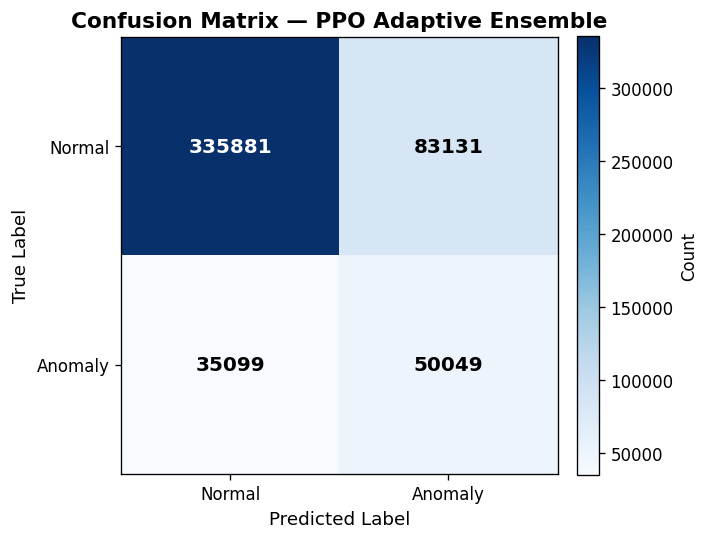

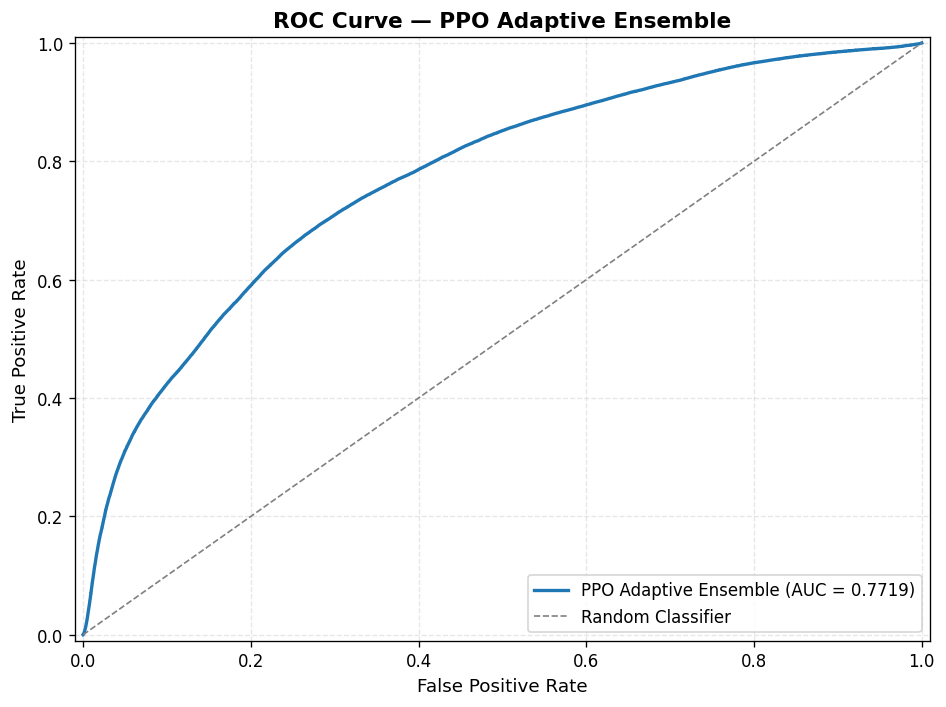

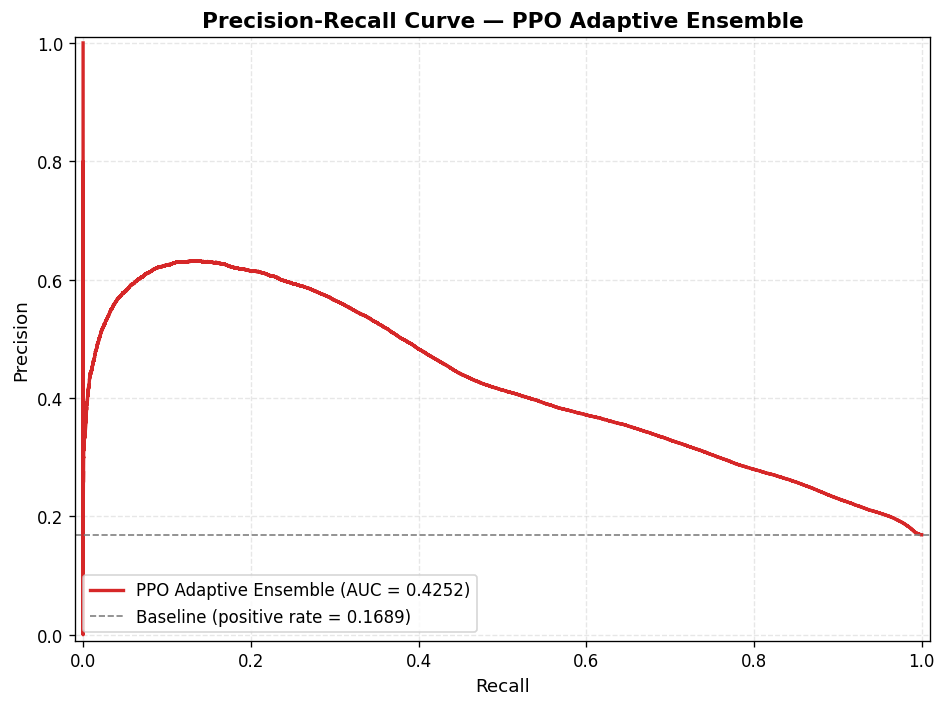

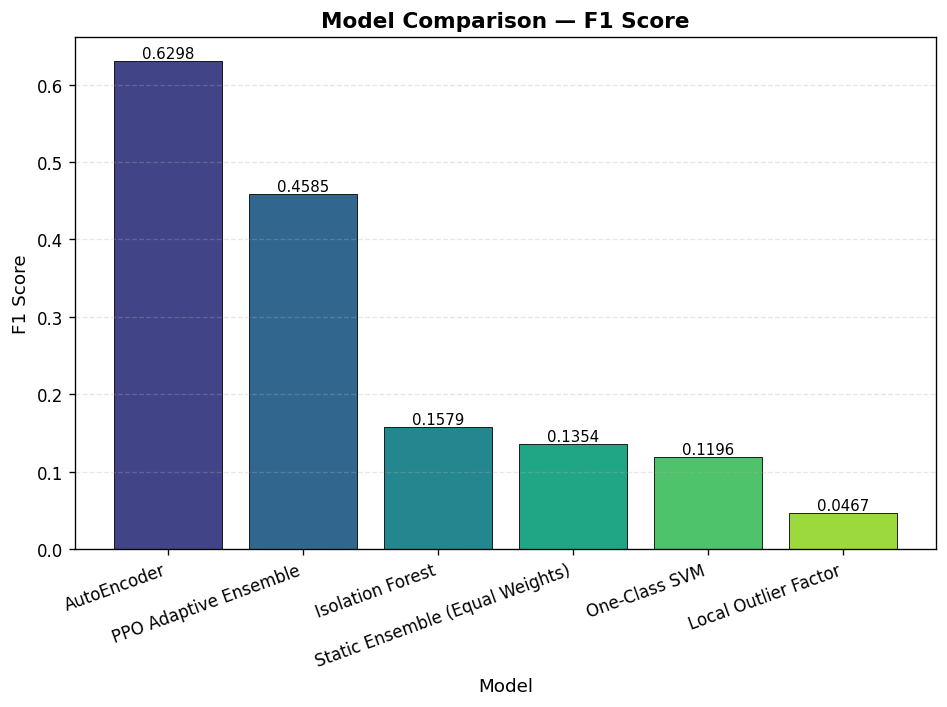

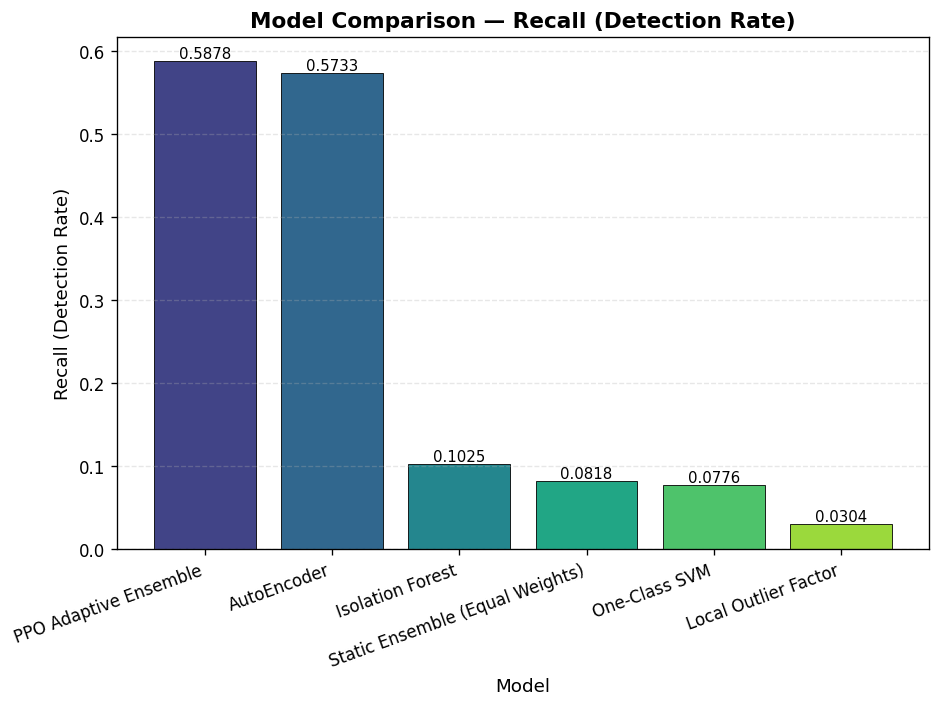

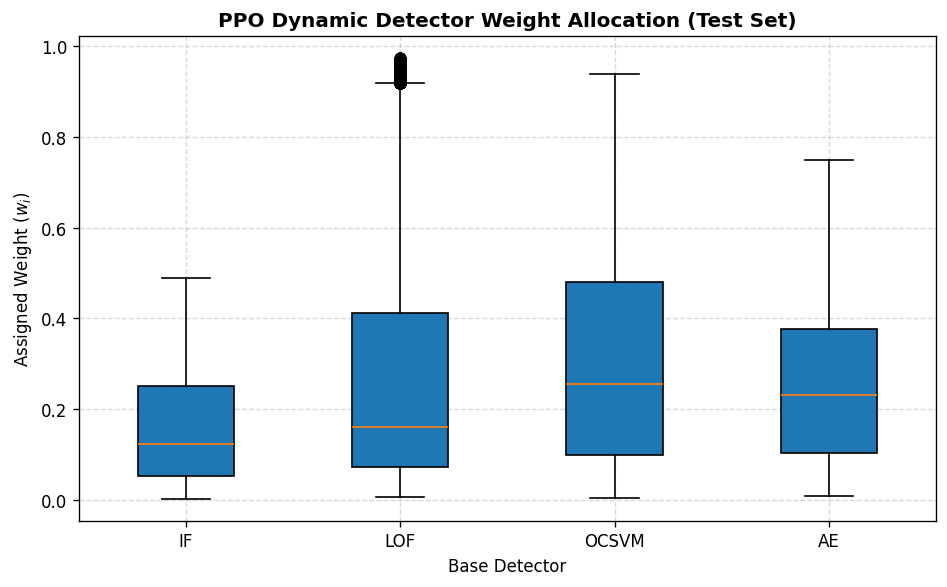


[OK] All publication figures rendered and saved to: /home/kalpe/projects/adaptive_rl_anomaly_detection/outputs/figures


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from src.evaluation.visualization import (
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall_curve,
    plot_model_comparison,
)

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 1. Confusion Matrix
fig_cm = plot_confusion_matrix(
    confusion_matrix=ppo_eval_result.confusion_matrix,
    model_name="PPO Adaptive Ensemble",
    class_names=["Normal", "Anomaly"],
)
fig_cm.savefig(FIGURES_DIR / "ppo_confusion_matrix.png", bbox_inches="tight")
plt.show()

# 2. ROC Curve
fig_roc = plot_roc_curve(
    y_true=y_test.to_numpy(),
    anomaly_scores=ppo_test_scores,
    model_name="PPO Adaptive Ensemble",
)
fig_roc.savefig(FIGURES_DIR / "ppo_roc_curve.png", bbox_inches="tight")
plt.show()

# 3. Precision-Recall Curve
fig_pr = plot_precision_recall_curve(
    y_true=y_test.to_numpy(),
    anomaly_scores=ppo_test_scores,
    model_name="PPO Adaptive Ensemble",
)
fig_pr.savefig(FIGURES_DIR / "ppo_precision_recall_curve.png", bbox_inches="tight")
plt.show()

# 4. F1-Score & Recall Comparisons across all paradigms
models = all_results["model_name"].tolist()
f1_scores = all_results["f1"].tolist()
recalls = all_results["recall"].tolist()

fig_f1 = plot_model_comparison(
    model_names=models,
    metric_values=f1_scores,
    metric_name="F1 Score",
    higher_is_better=True,
)
fig_f1.savefig(FIGURES_DIR / "model_comparison_f1.png", bbox_inches="tight")
plt.show()

fig_recall = plot_model_comparison(
    model_names=models,
    metric_values=recalls,
    metric_name="Recall (Detection Rate)",
    higher_is_better=True,
)
fig_recall.savefig(FIGURES_DIR / "model_comparison_recall.png", bbox_inches="tight")
plt.show()

# 5. Dynamic Weight Distribution Boxplot
fig_weights, ax = plt.subplots(figsize=(8, 5), dpi=120)
weights_data = [weights_df[f"weight_{name}"] for name in DETECTOR_NAMES]
ax.boxplot(weights_data, tick_labels=["IF", "LOF", "OCSVM", "AE"], patch_artist=True)
ax.set_title("PPO Dynamic Detector Weight Allocation (Test Set)", fontweight="bold")
ax.set_xlabel("Base Detector")
ax.set_ylabel("Assigned Weight ($w_i$)")
ax.grid(True, linestyle="--", alpha=0.5)
fig_weights.tight_layout()
fig_weights.savefig(FIGURES_DIR / "ppo_weight_distributions.png", bbox_inches="tight")
plt.show()

print(f"\n[OK] All publication figures rendered and saved to: {FIGURES_DIR}")

In [11]:
import json
import joblib
from pathlib import Path
import pandas as pd

print("=" * 70)
print("PERSISTING TEST EVALUATION ARTIFACTS (NOTEBOOK 24)")
print("=" * 70)

EVAL_DIR = PROJECT_ROOT / "evaluation_results"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save updated benchmark metrics matrix (CSV & LaTeX)
metrics_csv_path = EVAL_DIR / "metrics.csv"
all_results.to_csv(metrics_csv_path, index=False)

with open(REPORTS_DIR / "final_benchmark_table.tex", "w") as f:
    f.write(all_results.to_latex(index=False, float_format="%.4f"))

# Markdown table formatted directly without requiring the 'tabulate' package
headers = list(all_results.columns)
md_lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
for _, row in all_results.iterrows():
    md_lines.append("| " + " | ".join(f"{val:.4f}" if isinstance(val, float) else str(val) for val in row) + " |")

with open(REPORTS_DIR / "final_benchmark_table.md", "w") as f:
    f.write("\n".join(md_lines) + "\n")

print(f"[OK] Final benchmark metrics table saved -> {metrics_csv_path}")

# 2. Save comprehensive evaluation object (joblib)
ppo_results_path = EVAL_DIR / "ppo_test_results.joblib"
joblib.dump(
    {
        "ppo_eval_result": ppo_eval_result,
        "static_eval_result": static_eval_result,
        "test_scores": ppo_test_scores,
        "test_predictions": ppo_test_preds,
        "test_weights": ppo_test_weights,
        "weight_stats": weight_stats,
        "class_weights": class_weights,
    },
    ppo_results_path,
)
print(f"[OK] Evaluation results joblib saved -> {ppo_results_path}")

# 3. Save sample-level test predictions and dynamic weights (Parquet, 504,160 rows)
sample_results_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred_ppo": ppo_test_preds,
    "y_pred_static": static_test_preds,
    "ensemble_score_ppo": ppo_test_scores,
    "ensemble_score_static": static_test_scores,
    "weight_isolation_forest": ppo_test_weights[:, 0],
    "weight_lof": ppo_test_weights[:, 1],
    "weight_ocsvm": ppo_test_weights[:, 2],
    "weight_autoencoder": ppo_test_weights[:, 3],
})
sample_parquet_path = EVAL_DIR / "ppo_test_sample_predictions.parquet"
sample_results_df.to_parquet(sample_parquet_path, index=False)
print(f"[OK] Sample-level test predictions & weights saved -> {sample_parquet_path}")

# 4. Save dynamic weight statistics
weight_stats.to_csv(REPORTS_DIR / "ppo_weight_statistics.csv")
class_weights.to_csv(REPORTS_DIR / "ppo_class_weight_allocation.csv")
print(f"[OK] Dynamic weight statistics CSVs saved -> {REPORTS_DIR}")

# 5. Save final test evaluation manifest JSON
test_manifest = {
    "project": "Adaptive Reinforcement Learning Anomaly Detection",
    "stage": "Test Evaluation",
    "test_samples": int(len(y_test)),
    "checkpoint_evaluated": str(CHECKPOINT_PATH),
    "metrics": {
        "accuracy": float(ppo_eval_result.accuracy),
        "precision": float(ppo_eval_result.precision),
        "recall": float(ppo_eval_result.recall),
        "f1": float(ppo_eval_result.f1),
        "roc_auc": float(ppo_eval_result.roc_auc),
        "pr_auc": float(ppo_eval_result.pr_auc),
        "confusion_matrix": {
            "tn": int(ppo_eval_result.confusion_matrix[0, 0]),
            "fp": int(ppo_eval_result.confusion_matrix[0, 1]),
            "fn": int(ppo_eval_result.confusion_matrix[1, 0]),
            "tp": int(ppo_eval_result.confusion_matrix[1, 1]),
        },
    },
    "mean_weights": {
        "isolation_forest": float(weight_stats.loc["weight_isolation_forest", "mean"]),
        "lof": float(weight_stats.loc["weight_lof", "mean"]),
        "ocsvm": float(weight_stats.loc["weight_ocsvm", "mean"]),
        "autoencoder": float(weight_stats.loc["weight_autoencoder", "mean"]),
    },
}
manifest_path = EVAL_DIR / "final_evaluation_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(test_manifest, f, indent=4)
print(f"[OK] Final evaluation manifest saved -> {manifest_path}")

# 6. Confirm disk files
print("\n--- Verified Evaluation Files ---")
for p in [metrics_csv_path, ppo_results_path, sample_parquet_path, manifest_path]:
    size = f"{p.stat().st_size / (1024*1024):.2f} MB" if p.stat().st_size > 1024*1024 else f"{p.stat().st_size / 1024:.1f} KB"
    print(f"✓ {str(p.relative_to(PROJECT_ROOT)):<55} [{size}]")

PERSISTING TEST EVALUATION ARTIFACTS (NOTEBOOK 24)
[OK] Final benchmark metrics table saved -> /home/kalpe/projects/adaptive_rl_anomaly_detection/evaluation_results/metrics.csv
[OK] Evaluation results joblib saved -> /home/kalpe/projects/adaptive_rl_anomaly_detection/evaluation_results/ppo_test_results.joblib
[OK] Sample-level test predictions & weights saved -> /home/kalpe/projects/adaptive_rl_anomaly_detection/evaluation_results/ppo_test_sample_predictions.parquet
[OK] Dynamic weight statistics CSVs saved -> /home/kalpe/projects/adaptive_rl_anomaly_detection/outputs/reports
[OK] Final evaluation manifest saved -> /home/kalpe/projects/adaptive_rl_anomaly_detection/evaluation_results/final_evaluation_manifest.json

--- Verified Evaluation Files ---
✓ evaluation_results/metrics.csv                          [1.7 KB]
✓ evaluation_results/ppo_test_results.joblib              [23.08 MB]
✓ evaluation_results/ppo_test_sample_predictions.parquet  [19.80 MB]
✓ evaluation_results/final_evaluatio